**Step 1: Data Understanding and Visualization**

Classes found: ['tucuma', 'pupunha', 'cupuacu', 'guarana', 'graviola', 'acai']


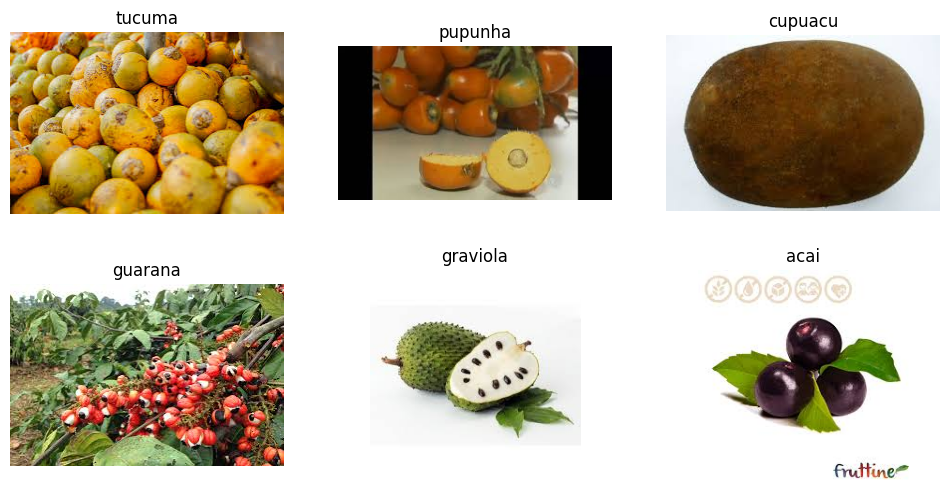

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to the training directory
train_dir = "/content/drive/MyDrive/AI_SEM5/csv_file/FruitinAmazon/train"

# Get list of class directories
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes found:", class_dirs)

# Randomly select one image per class
selected_images = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    if img_files: # Add this check
        selected_img = random.choice(img_files)
        selected_images.append(os.path.join(cls_path, selected_img))
    else:
        print(f"Warning: No image files found in {cls_path}. Skipping.")

# Display images in a 2-row grid
if selected_images:
    plt.figure(figsize=(12, 6))
    for i, img_path in enumerate(selected_images):
        img = Image.open(img_path)
        plt.subplot(2, (len(selected_images) + 1) // 2, i+1) # Adjusted subplot layout for odd number of images
        plt.imshow(img)
        plt.title(os.path.basename(os.path.dirname(img_path)))
        plt.axis('off')
    plt.show()
else:
    print("No images were selected to display.")

**Step 2: Check for Corrupted Images**

In [ ]:
corrupted_images = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        try:
            img = Image.open(img_path)
            img.verify()  # Will raise an error if corrupted
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")

No corrupted images found.


**Step 3: Loading and Preprocessing Data in Keras**

In [ ]:
import tensorflow as tf

# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


**Step 4: Implementing the CNN**

In [ ]:
from tensorflow.keras import layers, models

num_classes = len(class_dirs)  # Number of output classes

model = models.Sequential([
    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2), strides=2),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    # Flatten
    layers.Flatten(),

    # Fully connected layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Step 5: Compile the Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Step 6: Train the Model**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, mode='max')
earlystop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.1748 - loss: 2.8495

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 657ms/step - accuracy: 0.1806 - loss: 3.2960 - val_accuracy: 0.1667 - val_loss: 2.1111
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 736ms/step - accuracy: 0.2083 - loss: 1.8048 - val_accuracy: 0.0000e+00 - val_loss: 1.6743
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 594ms/step - accuracy: 0.2222 - loss: 1.7423 - val_accuracy: 0.0000e+00 - val_loss: 1.6660
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 518ms/step - accuracy: 0.1944 - loss: 1.7025 - val_accuracy: 0.0000e+00 - val_loss: 1.7962
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 0.2083 - loss: 1.6288 - val_accuracy: 0.0000e+00 - val_loss: 1.8357
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 0.3889 - loss: 1.4991 - val_accuracy: 0.0000e+00 - val_loss: 1.8473
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 0.4861 - loss: 1.3572 - val_accuracy: 0.0556 - val_loss: 1.8474
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 0.6667 - loss: 1.1995 - val_accuracy: 0.

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 810ms/step - accuracy: 0.6389 - loss: 1.0090 - val_accuracy: 0.6667 - val_loss: 1.0684
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 666ms/step - accuracy: 0.7222 - loss: 0.9152 - val_accuracy: 0.3333 - val_loss: 1.2178
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 459ms/step - accuracy: 0.8611 - loss: 0.6736 - val_accuracy: 0.2778 - val_loss: 1.5968
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8507 - loss: 0.5784

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 491ms/step - accuracy: 0.8333 - loss: 0.5785 - val_accuracy: 0.7778 - val_loss: 0.8946
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9161 - loss: 0.4232

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.8889 - loss: 0.4102 - val_accuracy: 0.8333 - val_loss: 0.6555
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step - accuracy: 0.9167 - loss: 0.3108 - val_accuracy: 0.5000 - val_loss: 0.9719
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 0.8889 - loss: 0.3026 - val_accuracy: 0.8333 - val_loss: 0.5526
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 798ms/step - accuracy: 0.9722 - loss: 0.1839 - val_accuracy: 0.8333 - val_loss: 0.4882
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 733ms/step - accuracy: 0.9861 - loss: 0.1327 - val_accuracy: 0.7778 - val_loss: 0.5602
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 514ms/step - accuracy: 0.9861 - loss: 0.1278 - val_accuracy: 0.7778 - val_loss: 0.5571
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 1.0000 - loss: 0.0796 - val_accuracy: 0.8333 - val_loss: 0.4072
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 1.0000 - loss: 0.0462

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 1.0000 - loss: 0.0489 - val_accuracy: 0.9444 - val_loss: 0.3805
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 0.9861 - loss: 0.0701 - val_accuracy: 0.8889 - val_loss: 0.3700
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 518ms/step - accuracy: 1.0000 - loss: 0.0334 - val_accuracy: 0.8333 - val_loss: 0.4618
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 689ms/step - accuracy: 1.0000 - loss: 0.0293 - val_accuracy: 0.7778 - val_loss: 0.4432
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 719ms/step - accuracy: 1.0000 - loss: 0.0287 - val_accuracy: 0.8333 - val_loss: 0.2330
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.9444 - val_loss: 0.2232
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.9444 - val_loss: 0.2805
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.9444 - val_lo

**Step 7: Evaluate, Save, Load, and Make Predictions**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
import tensorflow as tf # Import tensorflow to load the model

# Load the model
loaded_model = tf.keras.models.load_model("best_model.h5")

# Re-compile the loaded model to resolve the warning and prepare for potential evaluation
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the loaded model to build its metrics and suppress the warning
loss, acc = loaded_model.evaluate(val_ds, verbose=0) # verbose=0 to avoid redundant output

# Get true labels
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Make predictions
y_pred_prob = loaded_model.predict(val_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

# Use the 'class_dirs' variable which holds the class names
class_names = class_dirs

# Only use labels that actually exist in validation set
unique_labels = np.unique(y_true)

# Filter class names based on available labels
filtered_class_names = [class_names[i] for i in unique_labels]

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    labels=unique_labels,
    target_names=filtered_class_names,
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step

Classification Report:

              precision    recall  f1-score   support

    graviola       1.00      0.67      0.80         3
        acai       1.00      1.00      1.00        15

   micro avg       1.00      0.94      0.97        18
   macro avg       1.00      0.83      0.90        18
weighted avg       1.00      0.94      0.97        18

